# Hierarchical Agent Teams With RAG

**This project is inspired by the project of hierarchical agents by Krish Naik's RAG course.**

## Architecture

```
Top-Level Supervisor
├── Research Team
│   ├── Search Agent      ← Tavily web search
│   └── RAG Agent         ← Local vector store retrieval
└── Writing Team
    ├── Note Taker        ← Creates outlines
    ├── Doc Writer        ← Writes/edits documents
    └── Chart Generator   ← Produces charts via Python
```

The **RAG Agent** gives the research team access to a local knowledge base, so it can answer questions from pre-ingested documents without hitting the web every time.

## 1. Install dependencies

In [ ]:
%pip install -qU \
    langchain \
    langchain-openai \
    langchain-community \
    langchain-tavily \
    langgraph \
    faiss-cpu \
    langchain-experimental \
    beautifulsoup4

## 2. Environment / API Keys

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## 3. LLM Initialization

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 4. Shared State Definition

In [3]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState

class State(MessagesState):
    """Shared state for all agents. Extends MessagesState with a routing field."""
    next: str

## 5. Supervisor Factory

A reusable function that builds a supervisor node for any team. It uses structured output to route to the correct worker or `FINISH`.

In [4]:
from langchain_core.language_models.chat_models import BaseChatModel
from langgraph.graph import END
from langgraph.types import Command

def make_supervisor_node(llm: BaseChatModel, members: list[str]):
    """Returns a supervisor node that routes to one of `members` or FINISH."""
    options = ["FINISH"] + members
    system_prompt = (
        "You are a supervisor managing these workers: {members}.\n"
        "Given the conversation so far, choose which worker should act next.\n"
        "Each worker will complete a task and report back. "
        "When all work is done, respond with FINISH."
    ).format(members=members)

    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""
        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        messages = [{"role": "system", "content": system_prompt}] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END
        return Command(goto=goto, update={"next": goto})

    return supervisor_node

## 6. RAG Setup — Local Knowledge Base  ✦ NEW

We build a small in-memory FAISS vector store from a few sample documents. In a real project these would be your domain-specific PDFs, wikis, or database exports.

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# --- Sample knowledge base (replace with your own documents) ---
sample_texts = [
    """Transformer architecture was introduced by Vaswani et al. in 2017.
    It relies entirely on attention mechanisms and removes recurrence.
    The key innovation is multi-head self-attention, which allows the model
    to attend to different positions simultaneously.""",

    """BERT (Bidirectional Encoder Representations from Transformers) uses only
    the encoder stack of the transformer. It is pre-trained with Masked Language
    Modeling (MLM) and Next Sentence Prediction (NSP) objectives.
    BERT became the foundation of many NLP fine-tuning approaches.""",

    """GPT models use only the decoder stack and are trained autoregressively.
    GPT-3 has 175 billion parameters and demonstrated emergent few-shot
    learning abilities. GPT-4 extends this with multimodal inputs.""",

    """In production deployments, transformer models are optimized using
    techniques such as quantization (INT8/INT4), pruning, and knowledge
    distillation. Frameworks like ONNX Runtime and TensorRT are commonly
    used to accelerate inference on GPUs.""",

    """Parameter-Efficient Fine-Tuning (PEFT) methods like LoRA and Prefix Tuning
    allow large models to be adapted to new tasks by training only a small
    subset of parameters, reducing memory and compute costs significantly.""",
]

# Split & embed
splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
docs = splitter.create_documents(sample_texts)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"Vector store ready — {len(docs)} chunks indexed.")

Vector store ready — 5 chunks indexed.


## 7. Tool Definitions

### 7a. Research Tools

In [7]:
from typing import Annotated, List
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from tavily import TavilyClient

from langchain_community.document_loaders import WebBaseLoader

# Web search via Tavily
tavily_tool = TavilySearch(max_results=5)

@tool
def scrape_webpages(urls: List[str]) -> str:
    """Scrape one or more web pages and return their text content."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        f'<Document name="{doc.metadata.get("title", "")}">'  
        f'\n{doc.page_content}\n</Document>'
        for doc in docs
    )

# RAG retrieval tool  ✦ NEW
@tool
def retrieve_from_knowledge_base(query: str) -> str:
    """Search the local knowledge base for information relevant to the query.
    Use this before web search for topics that might be covered in internal documents."""
    results = retriever.invoke(query)
    if not results:
        return "No relevant documents found in the knowledge base."
    return "\n\n".join(
        f"[Chunk {i+1}]\n{doc.page_content}" for i, doc in enumerate(results)
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


### 7b. Writing Tools

In [8]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from langchain_experimental.utilities import PythonREPL
# PythonREPL is essentially a stateful Python execution environment that an LLM 
# (or your code) can call to run arbitrary Python code at runtime.

_TEMP_DIR = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_DIR.name)

@tool
def create_outline(
    points: Annotated[List[str], "List of main sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> str:
    """Create and save a numbered outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as f:
        for i, point in enumerate(points, 1):
            f.write(f"{i}. {point}\n")
    return f"Outline saved to {file_name}"

@tool
def write_document(
    content: Annotated[str, "Text content for the document."],
    file_name: Annotated[str, "File name to save to."],
) -> str:
    """Write content to a new text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as f:
        f.write(content)
    return f"Document saved to {file_name}"

@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to edit."],
    inserts: Annotated[
        Dict[int, str],
        "Dict mapping 1-indexed line numbers to text to insert at that line.",
    ],
) -> str:
    """Edit a document by inserting lines at specific positions."""
    with (WORKING_DIRECTORY / file_name).open("r") as f:
        lines = f.readlines()
    for line_number, text in sorted(inserts.items()):
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: line {line_number} out of range."
    with (WORKING_DIRECTORY / file_name).open("w") as f:
        f.writelines(lines)
    return f"Document edited: {file_name}"

@tool
def read_document(
    file_name: Annotated[str, "File path to read."],
    start: Annotated[Optional[int], "Start line (0-indexed). Default: 0."] = None,
    end: Annotated[Optional[int], "End line (exclusive). Default: all."] = None,
) -> str:
    """Read a saved document, optionally from a line range."""
    with (WORKING_DIRECTORY / file_name).open("r") as f:
        lines = f.readlines()
    return "".join(lines[start:end])

# Python REPL for chart generation
_repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "Python code to execute (e.g. for generating charts)."],
) -> str:
    """Execute Python code. Print values you want to see."""
    try:
        result = _repl.run(code)
    except BaseException as e:
        return f"Execution failed: {repr(e)}"
    return f"Executed successfully.\nStdout: {result}"

## 8. Research Team

Two workers: a **Search Agent** (web) and a **RAG Agent** (local knowledge base). A mid-level supervisor routes between them.

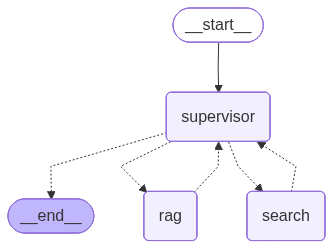

In [9]:
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START
from langchain.agents import create_agent

# --- Search agent (web) ---
search_agent = create_agent(
    llm,
    tools=[tavily_tool, scrape_webpages],
    system_prompt="You search the web and scrape pages to answer research questions. Be concise.",
)

def search_node(state: State) -> Command[Literal["supervisor"]]:
    result = search_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="search")]},
        goto="supervisor",
    )

# --- RAG agent (local knowledge base) ---  ✦ NEW
rag_agent = create_agent(
    llm,
    tools=[retrieve_from_knowledge_base],
    system_prompt=(
        "You answer questions using the local knowledge base. "
        "Always call retrieve_from_knowledge_base first. "
        "If the knowledge base lacks sufficient information, say so clearly."
    ),
)

def rag_node(state: State) -> Command[Literal["supervisor"]]:
    result = rag_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="rag")]},
        goto="supervisor",
    )

# --- Research supervisor ---
research_supervisor = make_supervisor_node(llm, ["search", "rag"])

# --- Build research subgraph ---
research_builder = StateGraph(State)
research_builder.add_node("supervisor", research_supervisor)
research_builder.add_node("search", search_node)
research_builder.add_node("rag", rag_node)
research_builder.add_edge(START, "supervisor")
research_graph = research_builder.compile()

research_graph

## 9. Writing Team

Three workers: a **Note Taker** (outlines), a **Doc Writer** (writes/edits text), and a **Chart Generator** (Python charts).

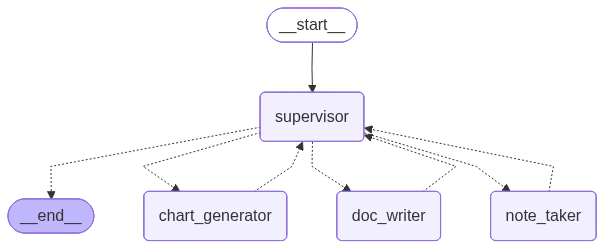

In [10]:
# --- Note-taking agent ---
note_taking_agent = create_agent(
    llm,
    tools=[create_outline, read_document],
    system_prompt="You read documents and create structured outlines for the doc writer. Don't ask follow-up questions.",
)

def note_taking_node(state: State) -> Command[Literal["supervisor"]]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="note_taker")]},
        goto="supervisor",
    )

# --- Doc-writing agent ---
doc_writer_agent = create_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    system_prompt="You write and edit documents following the note-taker's outlines. Don't ask follow-up questions.",
)

def doc_writing_node(state: State) -> Command[Literal["supervisor"]]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="doc_writer")]},
        goto="supervisor",
    )

# --- Chart-generating agent ---
chart_agent = create_agent(
    llm,
    tools=[read_document, python_repl_tool],
    system_prompt="You read documents and produce Python charts or tables. Don't ask follow-up questions.",
)

def chart_generating_node(state: State) -> Command[Literal["supervisor"]]:
    result = chart_agent.invoke(state)
    return Command(
        update={"messages": [HumanMessage(content=result["messages"][-1].content, name="chart_generator")]},
        goto="supervisor",
    )

# --- Writing supervisor ---
writing_supervisor = make_supervisor_node(llm, ["note_taker", "doc_writer", "chart_generator"])

# --- Build writing subgraph ---
writing_builder = StateGraph(State)
writing_builder.add_node("supervisor", writing_supervisor)
writing_builder.add_node("note_taker", note_taking_node)
writing_builder.add_node("doc_writer", doc_writing_node)
writing_builder.add_node("chart_generator", chart_generating_node)
writing_builder.add_edge(START, "supervisor")
paper_writing_graph = writing_builder.compile()

paper_writing_graph

## 10. Top-Level Supervisor

Composes the two subgraphs under a single entry point.

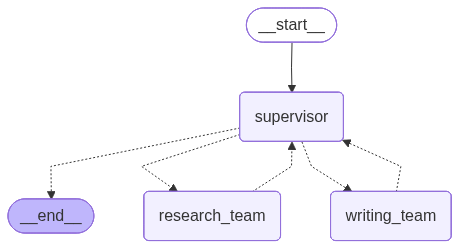

In [11]:
teams_supervisor = make_supervisor_node(llm, ["research_team", "writing_team"])

def call_research_team(state: State) -> Command[Literal["supervisor"]]:
    response = research_graph.invoke({"messages": state["messages"][-1:]})
    return Command(
        update={"messages": [HumanMessage(content=response["messages"][-1].content, name="research_team")]},
        goto="supervisor",
    )

def call_writing_team(state: State) -> Command[Literal["supervisor"]]:
    response = paper_writing_graph.invoke({"messages": state["messages"][-1:]})
    return Command(
        update={"messages": [HumanMessage(content=response["messages"][-1].content, name="writing_team")]},
        goto="supervisor",
    )

super_builder = StateGraph(State)
super_builder.add_node("supervisor", teams_supervisor)
super_builder.add_node("research_team", call_research_team)
super_builder.add_node("writing_team", call_writing_team)
super_builder.add_edge(START, "supervisor")
super_graph = super_builder.compile()

super_graph

## 11. Run — Test with a RAG-heavy query

We use a topic covered in our local knowledge base so the RAG agent should contribute. The writing team then drafts a short report.

In [12]:
response = super_graph.invoke(
    {
        "messages": [
            ("user", "Write a short report about transformer variants in production deployments.")
        ]
    }
)

Python REPL can execute arbitrary code. Use with caution.


In [13]:
print(response["messages"][-1].content)

The report on Transformer Variants in Production Deployments has been successfully saved. Additionally, I attempted to create a performance chart for the transformer variants, but it seems that the necessary library for plotting is not available in this environment.

If you would like, I can provide you with the code to generate the chart on your local machine. Would you like that?


## 12. Quick Smoke Test — RAG only

Bypass the full graph and invoke just the RAG agent to confirm the retriever works.

In [14]:
rag_response = rag_agent.invoke(
    {"messages": [("user", "What optimization techniques are used for transformer inference?")]}
)
print(rag_response["messages"][-1].content)

Optimization techniques used for transformer inference include:

1. **Quantization**: This involves reducing the precision of the model weights, such as using INT8 or INT4 formats, which can significantly decrease the model size and improve inference speed.

2. **Pruning**: This technique removes less important weights from the model, leading to a smaller and faster model without a significant loss in performance.

3. **Knowledge Distillation**: This method involves training a smaller model (the student) to replicate the behavior of a larger model (the teacher), allowing for efficient inference with reduced resource requirements.

4. **Parameter-Efficient Fine-Tuning (PEFT)**: Techniques like LoRA (Low-Rank Adaptation) and Prefix Tuning allow large models to be adapted to new tasks by training only a small subset of parameters, which reduces memory and compute costs.

5. **Frameworks for Acceleration**: Tools like ONNX Runtime and TensorRT are commonly used to accelerate inference on G